In [ ]:
import pathlib
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence


In [ ]:
# https://www.kaggle.com/code/ahnc2171/cmi-nnn

DATA_DIR = pathlib.Path('/Users/ashhadulislam/projects/general_data/CMI/ Detect Behavior with Sensor Data/cmi-detect-behavior-with-sensor-data/')  

train_path      = os.path.join(DATA_DIR, "train.csv")
test_path       = os.path.join(DATA_DIR, "test.csv")          #
train_demo_path = os.path.join(DATA_DIR, "train_demographics.csv")
test_demo_path  = os.path.join(DATA_DIR, "test_demographics.csv")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)
train_demo = pd.read_csv(train_demo_path)
test_demo  = pd.read_csv(test_demo_path)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train demo :", train_demo.shape)
train_df = train_df.merge(train_demo, on="subject", how="left")

TOF_COLS = [c for c in train_df.columns if c.startswith("tof_")]
THM_COLS = [c for c in train_df.columns if c.startswith("thm_")]

print("Num ToF cols:", len(TOF_COLS))
print("Num Thermal cols:", len(THM_COLS))


IMU_BASE_COLS = [
    "acc_x","acc_y","acc_z",
    "rot_w","rot_x","rot_y","rot_z"
]

IMU_FEATURE_NAMES = [
    "acc_x", "acc_y", "acc_z",
    "rot_6d_0", "rot_6d_1", "rot_6d_2",
    "rot_6d_3", "rot_6d_4", "rot_6d_5",
    "angular_vel_x", "angular_vel_y", "angular_vel_z",
    "linear_acc_x", "linear_acc_y", "linear_acc_z",
    "jerk_x", "jerk_y", "jerk_z",
    "acc_mag", "jerk_mag",
]

def normalize_quaternion(quat: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(quat, axis=-1, keepdims=True)
    norm = np.where(norm > 1e-8, norm, 1.0)
    return quat / norm


In [ ]:
# https://www.kaggle.com/code/ahnc2171/cmi-nnn




AE_IMU_COLS = [
    "acc_x", "acc_y", "acc_z",
    "rot_x", "rot_y", "rot_z", "rot_w",
]

def preprocess_sequence_for_ae(grp: pd.DataFrame) -> pd.DataFrame:
    # 1. Sort sequence
    grp = grp.sort_values("sequence_counter").reset_index(drop=True)

    # 2. Fill missing IMU values (lightweight)
    grp[AE_IMU_COLS] = grp[AE_IMU_COLS].replace([np.inf, -np.inf], np.nan)
    grp[AE_IMU_COLS] = grp[AE_IMU_COLS].ffill().bfill().fillna(0.0)

    # 3. Quaternion normalization (validity, NOT feature extraction)
    quat = grp[["rot_x", "rot_y", "rot_z", "rot_w"]].values.astype(np.float32)
    quat = normalize_quaternion(quat)
    grp[["rot_x", "rot_y", "rot_z", "rot_w"]] = quat

    # 4. Per-channel normalization (dataset-stable)
    eps = 1e-6
    for c in AE_IMU_COLS:
        mu = grp[c].mean()
        std = grp[c].std()
        if std < eps:
            std = eps
        grp[c] = (grp[c] - mu) / std

    return grp

In [ ]:
IMU_FEATURE_COLS = IMU_FEATURE_NAMES
TOF_FEATURE_COLS = TOF_COLS
THM_FEATURE_COLS = THM_COLS

In [ ]:
gestures = sorted(train_df["gesture"].unique())
gesture2idx = {g: i for i, g in enumerate(gestures)}
idx2gesture = {i: g for g, i in gesture2idx.items()}
num_classes = len(gestures)
print("Num gesture classes:", num_classes)

train_df["y_multi"] = train_df["gesture"].map(gesture2idx).astype(int)
train_df["y_bin"]   = (train_df["sequence_type"] == "target").astype(int)

# ============================================================
# 5b. METRIC CHUẨN: HIERARCHICAL MACRO F1 (BINARY + MULTICLASS)
# ============================================================
TARGET_GESTURES = [
    'Above ear - pull hair',
    'Cheek - pinch skin',
    'Eyebrow - pull hair',
    'Eyelash - pull hair',
    'Forehead - pull hairline',
    'Forehead - scratch',
    'Neck - pinch skin',
    'Neck - scratch',
]

NON_TARGET_GESTURES = [
    'Write name on leg',
    'Wave hello',
    'Glasses on/off',
    'Text on phone',
    'Write name in air',
    'Feel around in tray and pull out an object',
    'Scratch knee/leg skin',
    'Pull air toward your face',
    'Drink from bottle/cup',
    'Pinch knee/leg skin',
]

ALL_GESTURES_SET = set(TARGET_GESTURES + NON_TARGET_GESTURES)

In [ ]:
train_df_ae = (
    train_df
    .groupby("sequence_id", group_keys=False)
    .apply(preprocess_sequence_for_ae)
)

print("AE-ready train shape:", train_df_ae.shape)

In [ ]:
train_df_ae.head()

In [90]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# ResNet1D blocks (Conv1D)
# ----------------------------
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1):
        super().__init__()
        padding = kernel_size // 2

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=padding, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=1, padding=padding, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)

        if in_ch != out_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity
        return F.relu(out)


class ResNet1DEncoder(nn.Module):
    """
    Input:  (B, T, C)
    Output: (B, T, latent_dim)
    """
    def __init__(self, in_ch=7, latent_dim=64):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.layer1 = ResBlock1D(64, 64)
        self.layer2 = ResBlock1D(64, 128)
        self.layer3 = ResBlock1D(128, latent_dim)

    def forward(self, x):
        # x: (B, T, C) -> (B, C, T)
        x = x.transpose(1, 2)
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        # back to (B, T, latent_dim)
        return x.transpose(1, 2)


class ResNet1DDecoder(nn.Module):
    """
    Input:  (B, T, latent_dim)
    Output: (B, T, out_ch)
    """
    def __init__(self, latent_dim=64, out_ch=7):
        super().__init__()
        self.layer1 = ResBlock1D(latent_dim, 128)
        self.layer2 = ResBlock1D(128, 64)
        self.layer3 = ResBlock1D(64, 64)

        self.out = nn.Conv1d(64, out_ch, kernel_size=7, padding=3, bias=True)

    def forward(self, z):
        # z: (B, T, latent_dim) -> (B, latent_dim, T)
        z = z.transpose(1, 2)
        z = self.layer1(z)
        z = self.layer2(z)
        z = self.layer3(z)
        x_hat = self.out(z)
        return x_hat.transpose(1, 2)


class ResNet1DAutoEncoder(nn.Module):
    def __init__(self, in_ch=7, latent_dim=64):
        super().__init__()
        self.encoder = ResNet1DEncoder(in_ch=in_ch, latent_dim=latent_dim)
        self.decoder = ResNet1DDecoder(latent_dim=latent_dim, out_ch=in_ch)

    def forward(self, x):
        z = self.encoder(x)      # (B, T, latent_dim)
        x_hat = self.decoder(z)  # (B, T, 7)
        return x_hat, z



def train_one_epoch_ae(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for x, lengths, gestures in loader:
        x = x.to(device)  # (B, T, 7)

        optimizer.zero_grad()
        x_hat, z = model(x)

        # Plain reconstruction loss
        loss = F.mse_loss(x_hat, x)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(1, n_batches)




class IMUSequenceDataset(Dataset):
    def __init__(self, df):
        self.samples = []
        for _, grp in df.groupby("sequence_id"):
            x = grp[AE_IMU_COLS].values.astype("float32")
            gesture = grp["gesture"].iloc[0]
            self.samples.append((torch.tensor(x), gesture))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def collate_fn(batch):
    xs, gestures = zip(*batch)
    lengths = torch.tensor([x.shape[0] for x in xs])
    padded = pad_sequence(xs, batch_first=True)
    return padded, lengths, gestures



device = 'mps'
# ----------------------------
# Training loop
# ----------------------------
dataset = IMUSequenceDataset(train_df_ae)
loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

latent_dim=16
model = ResNet1DAutoEncoder(in_ch=len(AE_IMU_COLS), latent_dim=latent_dim).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)



EPOCHS = 20
for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch_ae(model, loader, optimizer, device)
    print(f"Epoch {epoch:02d}/{EPOCHS} | AE recon loss: {loss:.6f}")

Epoch 02/20 | AE recon loss: 0.026170
Epoch 03/20 | AE recon loss: 0.016065
Epoch 04/20 | AE recon loss: 0.011624
Epoch 05/20 | AE recon loss: 0.009220
Epoch 06/20 | AE recon loss: 0.008118
Epoch 07/20 | AE recon loss: 0.007627
Epoch 08/20 | AE recon loss: 0.006143
Epoch 09/20 | AE recon loss: 0.005857
Epoch 10/20 | AE recon loss: 0.005045
Epoch 11/20 | AE recon loss: 0.004757
Epoch 12/20 | AE recon loss: 0.004445
Epoch 13/20 | AE recon loss: 0.003763
Epoch 14/20 | AE recon loss: 0.003891
Epoch 15/20 | AE recon loss: 0.003692
Epoch 16/20 | AE recon loss: 0.003063
Epoch 17/20 | AE recon loss: 0.003392
Epoch 18/20 | AE recon loss: 0.002800
Epoch 19/20 | AE recon loss: 0.003066
Epoch 20/20 | AE recon loss: 0.002351


### Build timestep-level gesture colors

In [94]:
all_z = []
all_gestures = []

model.eval()
with torch.no_grad():
    for x, lengths, gestures in loader:
        x = x.to(device)
        _, z = model(x)

        for i in range(z.shape[0]):
            T = lengths[i].item()
            zi = z[i, :T].cpu().numpy()
            all_z.append(zi)
            all_gestures.extend([gestures[i]] * T)

        if len(all_z)>10000:
            break        

Z = np.concatenate(all_z, axis=0)

In [95]:
# PCA
## 4 -> 3
from sklearn.decomposition import PCA
pca_n_components=8
pca = PCA(n_components=pca_n_components, random_state=42)
Z_pca = pca.fit_transform(Z)

print("Explained variance:", pca.explained_variance_ratio_.sum())

# 3-> 2
import umap

umap_n_components=2
umap_model = umap.UMAP(
    n_components=umap_n_components,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

Z_umap = umap_model.fit_transform(Z_pca)

Explained variance: 0.9496802


/Users/ashhadulislam/miniconda3/envs/py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Plot colored by gesture
 - Do different gestures occupy different regions?

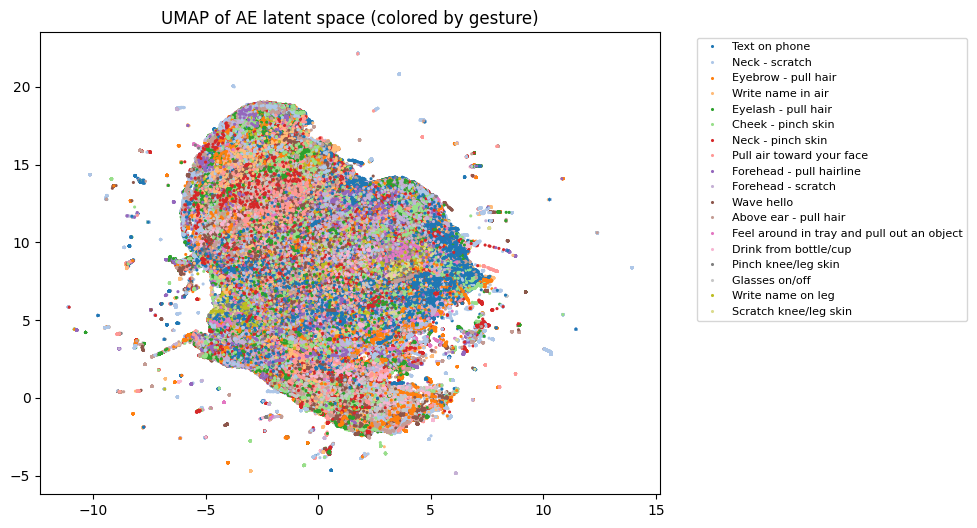

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=Z_umap[:, 0],
    y=Z_umap[:, 1],
    hue=all_gestures,
    palette="tab20",
    s=5,
    linewidth=0
)
plt.title("UMAP of AE latent space (colored by gesture)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.show()

### Binary classification

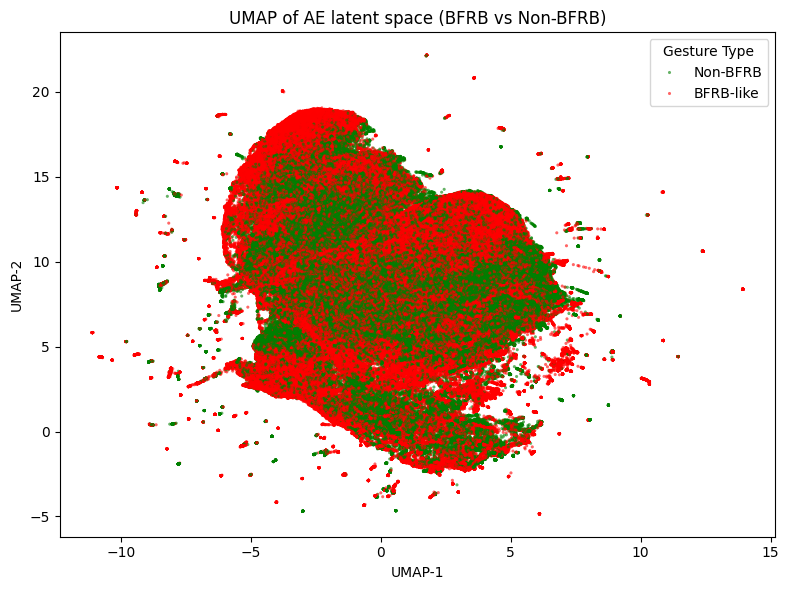

In [97]:
binary_labels = [
    "BFRB-like" if g in TARGET_GESTURES else "Non-BFRB"
    for g in all_gestures
]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=Z_umap[:, 0],
    y=Z_umap[:, 1],
    hue=binary_labels,
    palette={
        "BFRB-like": "red",
        "Non-BFRB": "green"
    },
    s=5,
    linewidth=0,
    alpha=0.6
)

plt.title("UMAP of AE latent space (BFRB vs Non-BFRB)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Gesture Type")
plt.tight_layout()
plt.show()

## Color by physics quantity (acceleration magnitude)


### Build timestep-aligned acceleration magnitude

In [98]:
acc_mag_all = []

with torch.no_grad():
    for x, lengths, _ in loader:
        for i in range(len(lengths)):
            T = lengths[i].item()
            acc = x[i, :T, :3].cpu().numpy()  # acc_x, acc_y, acc_z
            acc_mag = np.linalg.norm(acc, axis=1)
            acc_mag_all.append(acc_mag)

acc_mag_all = np.concatenate(acc_mag_all)

In [99]:
acc_mag_all.shape,Z_umap.shape

((574945,), (574945, 2))

### Plot physics-colored latent space

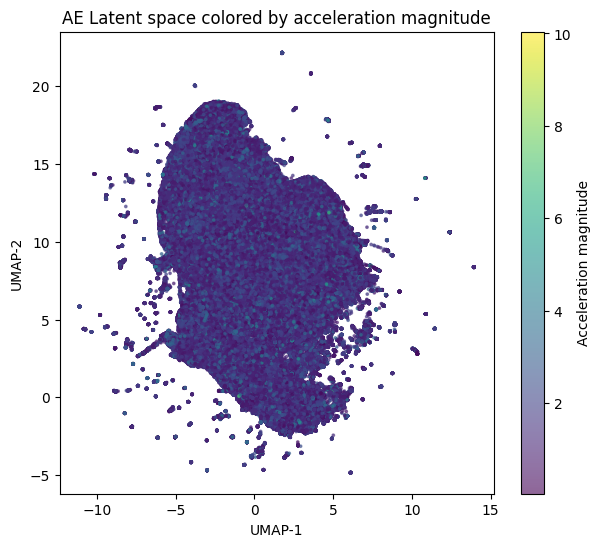

In [103]:
plt.figure(figsize=(7, 6))
plt.scatter(
    Z_umap[:, 0],
    Z_umap[:, 1],
    c=acc_mag_all[:Z_umap.shape[0]],
    cmap="viridis",
    s=3,
    alpha=0.6
)
plt.colorbar(label="Acceleration magnitude")
plt.title("AE Latent space colored by acceleration magnitude")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

## B. Compute physics targets correctly


In [ ]:
dt = 1.0

In [104]:
import numpy as np

def quat_normalize(q):
    # q: (..., 4) in (x,y,z,w)
    norm = np.linalg.norm(q, axis=-1, keepdims=True)
    norm = np.where(norm > 1e-8, norm, 1.0)
    return q / norm

def quat_conj(q):
    # (x,y,z,w) -> (-x,-y,-z,w)
    qc = q.copy()
    qc[..., :3] *= -1
    return qc

def quat_mul(q1, q2):
    # Hamilton product, both (...,4) with (x,y,z,w)
    x1,y1,z1,w1 = q1[...,0], q1[...,1], q1[...,2], q1[...,3]
    x2,y2,z2,w2 = q2[...,0], q2[...,1], q2[...,2], q2[...,3]
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    return np.stack([x,y,z,w], axis=-1)

def quat_rotate_vec(q, v):
    # Rotate vector(s) v by quaternion q
    # q: (...,4), v: (...,3)
    q = quat_normalize(q)
    v_as_quat = np.concatenate([v, np.zeros((*v.shape[:-1], 1), dtype=v.dtype)], axis=-1)
    return quat_mul(quat_mul(q, v_as_quat), quat_conj(q))[..., :3]

2) Angular velocity from quaternion sequence


In [105]:
def quat_to_angvel(q, dt=1.0):
    """
    q: (T,4) quaternions in (x,y,z,w), assumed normalized
    returns omega: (T,3) angular velocity; omega[0]=0
    """
    q = quat_normalize(q)
    q_next = q[1:]
    q_curr = q[:-1]
    q_rel = quat_mul(q_next, quat_conj(q_curr))  # (T-1,4)
    q_rel = quat_normalize(q_rel)

    # Ensure shortest path (optional but helps stability)
    # If w < 0, flip quaternion sign
    flip = (q_rel[:, 3] < 0).astype(np.float32)
    q_rel[flip == 1] *= -1

    w = np.clip(q_rel[:, 3], -1.0, 1.0)
    angle = 2.0 * np.arccos(w)  # (T-1,)

    sin_half = np.sqrt(1.0 - w*w)  # = sin(angle/2)
    axis = np.zeros((q_rel.shape[0], 3), dtype=np.float32)
    small = sin_half < 1e-6
    axis[~small] = q_rel[~small, :3] / sin_half[~small, None]
    axis[small] = np.array([1.0, 0.0, 0.0], dtype=np.float32)  # arbitrary

    omega = (angle / dt)[:, None] * axis  # (T-1,3)

    omega_full = np.zeros((q.shape[0], 3), dtype=np.float32)
    omega_full[1:] = omega
    return omega_full

3) Gravity-compensated linear acceleration


In [106]:
def linear_acc_from_quat_acc(acc, q, g=1.0):
    """
    acc: (T,3) raw accelerometer
    q:   (T,4) orientation quaternion (x,y,z,w)
    returns linear_acc: (T,3)
    """
    q = quat_normalize(q)
    g_world = np.array([0.0, 0.0, -g], dtype=np.float32)  # choose convention
    g_world = np.repeat(g_world[None, :], acc.shape[0], axis=0)
    g_sens = quat_rotate_vec(q, g_world)  # gravity direction in sensor coords
    linear_acc = acc - g_sens
    return linear_acc

4) Jerk from linear acceleration

In [107]:
def jerk(linear_acc, dt=1.0):
    j = np.zeros_like(linear_acc, dtype=np.float32)
    j[1:] = (linear_acc[1:] - linear_acc[:-1]) / dt
    return j

## C. Build “actual vs latent” probe dataset (aligned correctly)


In [108]:
from torch.utils.data import DataLoader

probe_loader = DataLoader(dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [109]:
seq_meta = []
for seq_id, grp in train_df_ae.groupby("sequence_id"):
    seq_meta.append({
        "sequence_id": seq_id,
        "subject": grp["subject"].iloc[0],
        "gesture": grp["gesture"].iloc[0],
    })

In [110]:
import numpy as np

def build_probe_arrays(model, probe_loader, seq_meta, device, dt=1.0):
    model.eval()

    Z_all = []
    Y_lin = []
    Y_omg = []
    Y_jrk = []
    subj_all = []

    seq_idx = 0  # tracks which sequence in seq_meta we are on

    with torch.no_grad():
        for x, lengths, gestures in probe_loader:
            x_np = x.numpy()  # (B,T,7) on CPU
            x = x.to(device)
            _, z = model(x)   # (B,T,d)
            z = z.cpu().numpy()

            for i in range(x_np.shape[0]):
                T = lengths[i].item()

                # latent
                zi = z[i, :T]  # (T,d)

                # raw imu
                acc = x_np[i, :T, 0:3].astype(np.float32)
                quat = x_np[i, :T, 3:7].astype(np.float32)  # rot_x,rot_y,rot_z,rot_w

                quat = quat_normalize(quat)
                omega = quat_to_angvel(quat, dt=dt)                  # (T,3)
                linacc = linear_acc_from_quat_acc(acc, quat, g=1.0)  # (T,3)
                jrk = jerk(linacc, dt=dt)                            # (T,3)

                Z_all.append(zi)
                Y_lin.append(linacc)
                Y_omg.append(omega)
                Y_jrk.append(jrk)

                subj_all.extend([seq_meta[seq_idx]["subject"]] * T)
                seq_idx += 1

    Z_all = np.concatenate(Z_all, axis=0)
    Y_lin = np.concatenate(Y_lin, axis=0)
    Y_omg = np.concatenate(Y_omg, axis=0)
    Y_jrk = np.concatenate(Y_jrk, axis=0)
    subj_all = np.array(subj_all)

    return Z_all, Y_lin, Y_omg, Y_jrk, subj_all

In [111]:
Z_all, Y_lin, Y_omg, Y_jrk, subj_all = build_probe_arrays(
    model, probe_loader, seq_meta, device, dt=1.0
)

print(Z_all.shape, Y_lin.shape, Y_omg.shape, Y_jrk.shape, subj_all.shape)

(574945, 16) (574945, 3) (574945, 3) (574945, 3) (574945,)


## D. Train probes (linear) + evaluate


In [112]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def eval_probe(Z, Y, groups, name="target"):
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    (train_idx, test_idx), = splitter.split(Z, Y, groups=groups)

    Ztr, Zte = Z[train_idx], Z[test_idx]
    Ytr, Yte = Y[train_idx], Y[test_idx]

    # Ridge regression = strong linear probe baseline
    probe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    probe.fit(Ztr, Ytr)
    Yhat = probe.predict(Zte)

    # vector metrics
    r2_axes = [r2_score(Yte[:,k], Yhat[:,k]) for k in range(Y.shape[1])]
    mae_axes = [mean_absolute_error(Yte[:,k], Yhat[:,k]) for k in range(Y.shape[1])]
    r2_mean = float(np.mean(r2_axes))
    mae_mean = float(np.mean(mae_axes))

    # cosine similarity
    num = np.sum(Yte * Yhat, axis=1)
    den = (np.linalg.norm(Yte, axis=1) * np.linalg.norm(Yhat, axis=1) + 1e-8)
    cos = float(np.mean(num / den))

    print(f"[{name}] R2 axes={r2_axes}, mean={r2_mean:.3f}")
    print(f"[{name}] MAE axes={mae_axes}, mean={mae_mean:.3f}")
    print(f"[{name}] Cosine similarity mean={cos:.3f}")

    return probe

In [113]:
probe_lin = eval_probe(Z_all, Y_lin, subj_all, name="linear_acc")
probe_omg = eval_probe(Z_all, Y_omg, subj_all, name="ang_vel")
probe_jrk = eval_probe(Z_all, Y_jrk, subj_all, name="jerk")

[linear_acc] R2 axes=[0.6276109218597412, 0.63527512550354, 0.7754208445549011], mean=0.679
[linear_acc] MAE axes=[0.5900989770889282, 0.5896695256233215, 0.3827115595340729], mean=0.521
[linear_acc] Cosine similarity mean=0.748
[ang_vel] R2 axes=[0.015767216682434082, 0.02272486686706543, 0.002992570400238037], mean=0.014
[ang_vel] MAE axes=[0.21500340104103088, 0.22359918057918549, 0.19190798699855804], mean=0.210
[ang_vel] Cosine similarity mean=0.022
[jerk] R2 axes=[0.22019392251968384, 0.21266841888427734, 0.20833325386047363], mean=0.214
[jerk] MAE axes=[0.40162158012390137, 0.3505389988422394, 0.3246203660964966], mean=0.359
[jerk] Cosine similarity mean=0.248


## E. “Actual vs Predicted” plots 

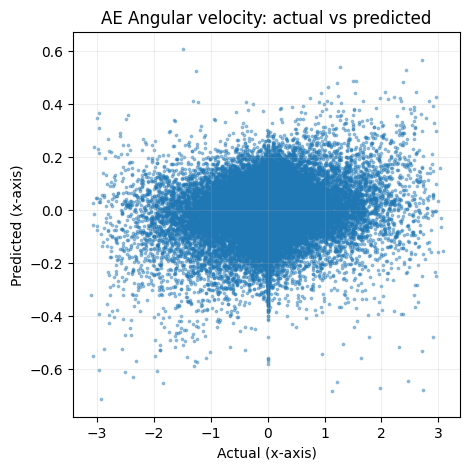

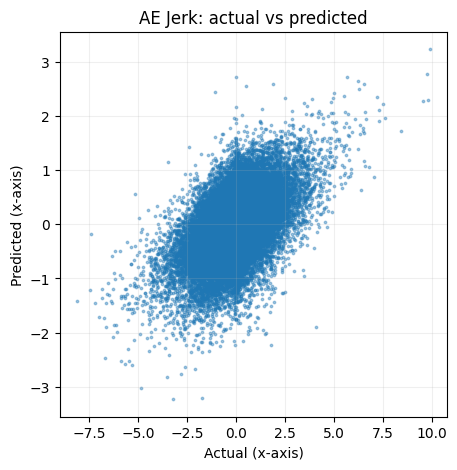

In [114]:
import matplotlib.pyplot as plt

def scatter_actual_vs_pred(probe, Z, Y, groups, title=""):
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    (train_idx, test_idx), = splitter.split(Z, Y, groups=groups)
    Zte, Yte = Z[test_idx], Y[test_idx]

    Yhat = probe.predict(Zte)

    plt.figure(figsize=(5,5))
    plt.scatter(Yte[:,0], Yhat[:,0], s=3, alpha=0.4)
    plt.xlabel("Actual (x-axis)")
    plt.ylabel("Predicted (x-axis)")
    plt.title(title)
    plt.grid(True, alpha=0.2)
    plt.show()

scatter_actual_vs_pred(probe_omg, Z_all, Y_omg, subj_all, title="AE Angular velocity: actual vs predicted")
scatter_actual_vs_pred(probe_jrk, Z_all, Y_jrk, subj_all, title="AE Jerk: actual vs predicted")